### Analysis of an E-commerce Dataset

We have been provided with a combined e-commerce dataset. In this dataset, each user has the ability to post a rating and review for the products they purchased. Additionally, other users can evaluate the initial rating and review by expressing their trust or distrust.

This dataset includes a wealth of information for each user. Details such as their profile, ID, gender, city of birth, product ratings (on a scale of 1-5), reviews, and the prices of the products they purchased are all included. Moreover, for each product rating, we have information about the product name, ID, price, and category, the rating score, the timestamp of the rating and review, and the average helpfulness of the rating given by others (on a scale of 1-5).

The dataset is from several data sources, and we have merged all the data into a single CSV file named 'A Combined E-commerce Dataset.csv'. The structure of this dataset is represented in the header shown below.

| userId | gender | rating | review| item | category | helpfulness | timestamp | item_id | item_price | user_city|

    | ---- | ---- | ---- | ---- | ---- | ---- | ---- | ---- | ---- |  ---- |  ---- |  
    
#### Description of Fields

* __userId__ - the user's id
* __gender__ - the user's gender
* __rating__ - the user's rating towards the item
* __review__ - the user's review towards the item
* __item__ - the item's name
* __category__ - the category of the item
* __helpfulness__ - the average helpfulness of this rating
* __timestamp__ - the timestamp when the rating is created
* __item_id__ - the item's id
* __item_price__ - the item's price
* __user_city__ - the city of user's birth

Note that, a user may rate multiple items and an item may receive ratings and reviews from multiple users. The "helpfulness" is an average value based on all the helpfulness values given by others.

There are four questions to explore with the data as shown below.



<img src="data-relation.png" align="left" width="400"/>
(You can find the data relation diagram on iLearn - Portfolio Part 1 resources - Fig1)


 #### Q1. Remove missing data

Please remove the following records in the csv file:

 * gender/rating/helpfulness is missing
 * review is 'none'

__Display the DataFrame, counting number of Null values in each column, and print the length of the data__ before and after removing the missing data.  

##### Answer to Question 1:

In [150]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

ds = '/Users/irfanakram/Documents/GitHub/Irfan6200/Portfolio Submission COMP6200/portfolio-part-1-IrfanA13/The E-commerce Dataset.csv'

In [183]:
#Question 1: Displaying Data Frame before removal of missing data.
df = pd.read_csv(ds)
df.head()

,userId,timestamp,review,item,rating,helpfulness,gender,category,item_id,item_price,user_city
0,4051,12807,Great job for what it is!,eBay,5.0,2.0,F,Online Stores & Services,88,149.00,39
1,4052,122899,Free Access Worth your Time,NetZero,5.0,0.0,F,Online Stores & Services,46,53.00,39
2,33,12700,AOL..I love you!!!!!!!!!!!!,AOL (America Online),5.0,4.0,F,Online Stores & Services,0,145.84,31
3,33,21000,EBAY!!! I LOVE YOU!!!! :-)*,eBay,5.0,4.0,F,Online Stores & Services,88,149.00,31
4,33,22300,Blair Witch...Oh Come On.......,Blair Witch Project,1.0,4.0,F,Movies,12,44.00,31


In [152]:
#Question 1: Counting number of Null values in each column, before removal of missing data.
count_null = df.isnull().sum()
print(count_null)

userId          0
timestamp       0
review          0
item            0
rating         17
helpfulness    22
gender         27
category        0
item_id         0
item_price      0
user_city       0
dtype: int64


In [153]:
#Question 1: lengh of data before removal of missing data.
print(len(df))

20000


In [154]:
#Question 1: Removing data missing data 
df_clean = df.dropna(subset=['gender','rating','helpfulness'])
df_clean = df_clean[df_clean['review'] != 'none']

In [155]:
#Question 1: Displaying Data Frame after removal of missing data.
df_clean.head()

,userId,timestamp,review,item,rating,helpfulness,gender,category,item_id,item_price,user_city
0,4051,12807,Great job for what it is!,eBay,5.0,2.0,F,Online Stores & Services,88,149.00,39
1,4052,122899,Free Access Worth your Time,NetZero,5.0,0.0,F,Online Stores & Services,46,53.00,39
2,33,12700,AOL..I love you!!!!!!!!!!!!,AOL (America Online),5.0,4.0,F,Online Stores & Services,0,145.84,31
3,33,21000,EBAY!!! I LOVE YOU!!!! :-)*,eBay,5.0,4.0,F,Online Stores & Services,88,149.00,31
4,33,22300,Blair Witch...Oh Come On.......,Blair Witch Project,1.0,4.0,F,Movies,12,44.00,31


In [184]:
#Question 1: Counting number of Null values in each column, after removal of missing data.
count_null1 = df_clean.isnull().sum()
print(count_null1)

userId         0
timestamp      0
review         0
item           0
rating         0
helpfulness    0
gender         0
category       0
item_id        0
item_price     0
user_city      0
dtype: int64


In [185]:
#Question 1: lengh of data after removal of missing data.
print(len(df_clean))

19916


#### Q2. Descriptive statistics

With the cleaned data in Q1, please provide the data summarization as below:

* Q2.1 total number of unique users, unique reviews, unique items, and unique categories
* Q2.2 descriptive statistics, e.g., the total number, mean, std, min and max regarding all rating records
* Q2.3 descriptive statistics, e.g., mean, std, max, and min of the number of items rated by different genders
* Q2.4 descriptive statistics, e.g., mean, std, max, min of the number of ratings that received by each items


##### Answer to Question 2:

In [158]:
#Question 2.1
# Total number of unique userId
unique_users = df_clean['userId'].nunique()

# Total number of unique reviews
unique_reviews = df_clean['review'].nunique()

# Total number of unique items
unique_items = df_clean['item_id'].nunique()

# Total number of unique categories
unique_categories = df_clean['category'].nunique()

print(unique_users)
print(unique_reviews)
print(unique_items)
print(unique_categories)

8562
19459
89
9


In [159]:
#Question 2.2: 
print(df_clean['rating'].describe())


count    19916.000000
mean         3.701798
std          1.404451
min          1.000000
25%          3.000000
50%          4.000000
75%          5.000000
max          5.000000
Name: rating, dtype: float64


In [160]:
#Question 2.3:
#Counting and displaying the number of items rated by different genders
gender_item_stats = df_clean.groupby('gender')['item'].describe()
print(gender_item_stats)
df_gender_group = df_clean.groupby('gender').count()['item'].reset_index(name='count')
print(df_gender_group)

        count unique                   top freq
gender                                         
F        9793     89  AOL (America Online)  457
M       10123     89  AOL (America Online)  482
  gender  count
0      F   9793
1      M  10123


In [161]:
#Question 2.3:
#Displaying the descriptive statistics for the number of items rated by different genders
df_gender_group['count'].describe()

count        2.000000
mean      9958.000000
std        233.345238
min       9793.000000
25%       9875.500000
50%       9958.000000
75%      10040.500000
max      10123.000000
Name: count, dtype: float64

In [162]:
#Question 2.4: 
item_rating_stats = df_clean.groupby('item')['rating'].describe()
print(item_rating_stats)

                       count      mean       std  min   25%  50%  75%  max
item                                                                      
AOL (America Online)   939.0  2.500532  1.368528  1.0  1.00  2.0  4.0  5.0
All Advantage          657.0  3.412481  1.541706  1.0  2.00  4.0  5.0  5.0
Alta Vista (by 1stUp)  157.0  3.541401  1.263341  1.0  3.00  4.0  4.0  5.0
Amazon.com             240.0  3.683333  1.571095  1.0  2.00  4.0  5.0  5.0
American Airlines      185.0  3.054054  1.417015  1.0  2.00  3.0  4.0  5.0
...                      ...       ...       ...  ...   ...  ...  ...  ...
Wendy's                210.0  3.971429  1.093322  1.0  3.25  4.0  5.0  5.0
What Lies Beneath      160.0  3.450000  1.201676  1.0  3.00  3.5  4.0  5.0
X-Men                  245.0  4.118367  0.853074  1.0  4.00  4.0  5.0  5.0
X.com                  173.0  4.023121  1.474409  1.0  3.00  5.0  5.0  5.0
eBay                   596.0  4.333893  0.949618  1.0  4.00  5.0  5.0  5.0

[89 rows x 8 columns]


#### Q3. Plotting and Analysis

Please try to explore the correlation between gender/helpfulness/category and ratings; for instance, do female/male users tend to provide higher ratings than male/female users? Hint: you may use the boxplot function to plot figures for comparison (___Challenge___)
    
You may need to select the most suitable graphic forms for ease of presentation. Most importantly, for each figure or subfigure, please summarise ___what each plot shows___ (i.e. observations and explanations). Finally, you may need to provide an overall summary of the data.

##### Answer to Question 3

<Axes: title={'center': 'rating'}, xlabel='gender'>

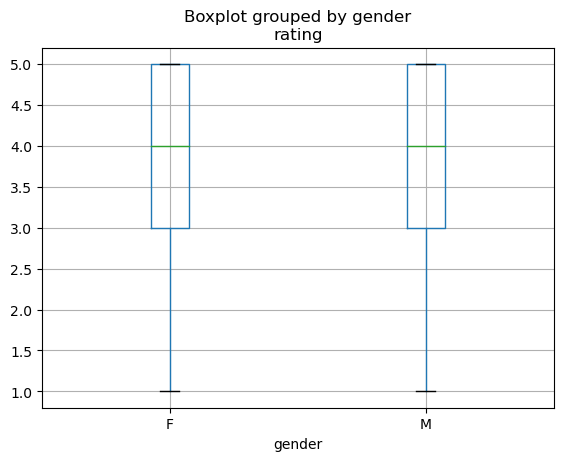

In [163]:
#Question 3.1: Correlation between gender and rating - represnted via boxplot.
df_clean.boxplot('rating', by = 'gender')

##### Answer to Question 3.1: Summary of box plot
The box plots compares the distribution of ratings for the differnet genders: Male & Female. For both gender groups, the median value =4, upper quartile = 5, and lower quartile = 3. 
The highest and lowest rating for each is 5 and 1 respectively. 
It can be assessed that the ratings of both genders are similarly distributed.

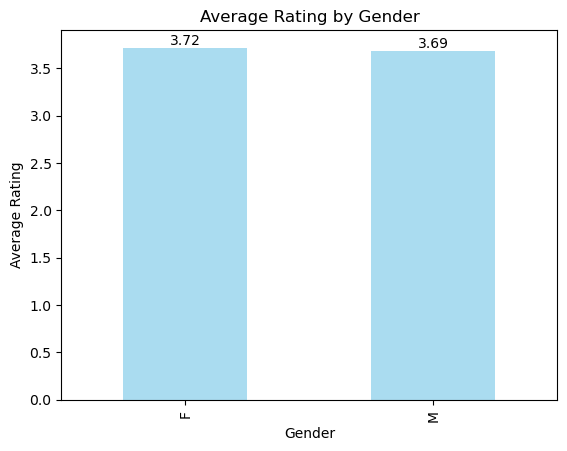

In [164]:
#Question 3.1: Correlation between gender and rating - represnted via bar chart.
gender_ratings = df_clean.groupby('gender')['rating'].mean()

# Plotting the bar chart
ax = gender_ratings.plot(kind='bar', color='skyblue', alpha=0.7)

# Adding labels and title to the plot
plt.xlabel('Gender')
plt.ylabel('Average Rating')
plt.title('Average Rating by Gender')

# Adding mean values as annotations
for i, mean_rating in enumerate(gender_ratings):
    ax.text(i, mean_rating, f'{mean_rating:.2f}', ha='center', va='bottom', color='black')

# Display the plot
plt.show()

##### Answer to Question 3.1: Summary of bar chart
The bar chart compares the mean rating accross the genders: Female vs Male. It can be seen that the mean of the Female (3.72) is higher than that of the Male (3.69).

<Axes: title={'center': 'rating'}, xlabel='helpfulness'>

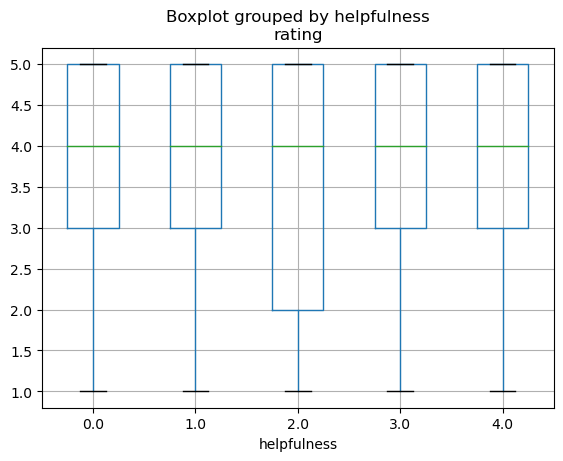

In [165]:
#Question 3.2: Correlation between helpfulness and rating - represented via boxplot.
df_clean.boxplot('rating', by = 'helpfulness')

##### Answer to Question 3.2: Summary of box plot
The box plots compares the distribution of ratings for the differnet scores of helpfulness. For scores 0,1,3,4 of helpfulness, the distribution of rating score is similar with lower quartile being 3 and upper quartile being 5, and median values being 4, with all the them representing a lowest value of 1.0 and highest value of 5.0 
Where as for helpfulness score of 2.0, it can be seen that the upper quarter and median is similar to the other scores; however, the lower quartile is 2 instead of 3. 

It can be assessed that the rating data distribution for each point of helpfullness is similar - with helpfullness value 2.0 sharing a larger interquartile range than the others. 

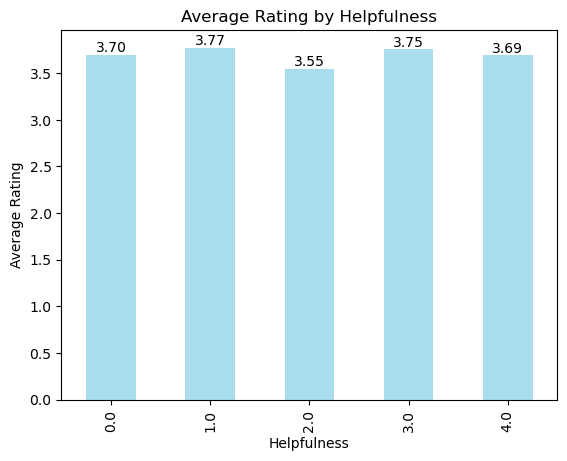

In [166]:
#Question 3.2: correlation between helpfulness and rating - represnted via bar chart.
helpfulness_ratings = df_clean.groupby('helpfulness')['rating'].mean()

# Plotting the bar chart
ax = helpfulness_ratings.plot(kind='bar', color='skyblue', alpha=0.7)

# Adding labels and title to the plot
plt.xlabel('Helpfulness')
plt.ylabel('Average Rating')
plt.title('Average Rating by Helpfulness')

# Adding mean values as annotations
for i, mean_rating in enumerate(helpfulness_ratings):
    ax.text(i, mean_rating, f'{mean_rating:.2f}', ha='center', va='bottom', color='black')

# Display the plot
plt.show()

##### Answer to Question 3.2: Summary of bar chart
The bar chart compares the mean rating accross the helpfullness scores. It can be seen that the mean rating for helpfulness score 2.0 is the lowest being (3.55) and highest for helpfulness 1.0 being (3.77). Mean ratings for the remaining helpfullness score values are (3.75) for 3.0, (3.70) for 0.0, and (3.69) for 4.00. 

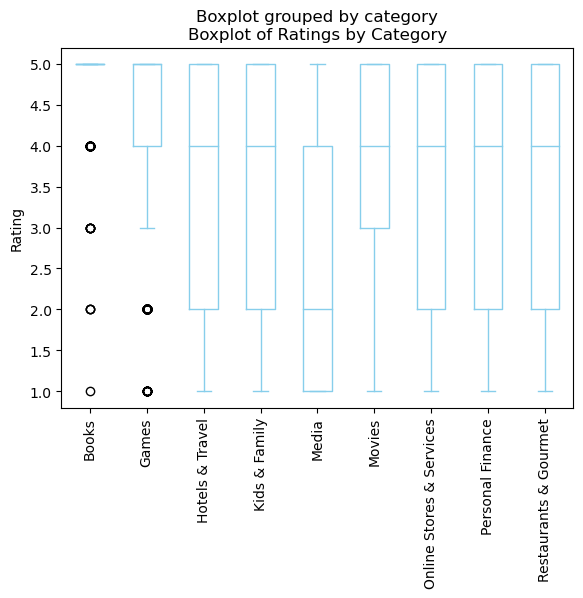

In [167]:
#Question 3.3: correlation between category and rating - represnted via box plot.
category_ratings = df_clean.groupby('category')['rating'].mean()

# Plotting the boxplot
ax = df_clean.boxplot(column='rating', by='category', color='skyblue', grid=False)

# Rotating category labels by 90 degrees
ax.set_xticklabels(ax.get_xticklabels(), rotation=90)

# Adding labels and title to the plot
plt.xlabel('Category')
plt.ylabel('Rating')
plt.title('Boxplot of Ratings by Category')

# Remove default xlabel
plt.xlabel('')

# Display the plot
plt.show()

##### Answer to Question 3.3: Summary of box plot
The box plots compares the distribution of ratings for the various categories. It can be seen that the distribution for categories: 'Hotels & Travels', 'kids & Family','Online Stores & Services', 'Personal Finance', & 'Restaurants & Gourmet' share a similar distribution with upper quartile 5 and lower quartile 2, with median 4. 

Whereas, Movies represnt a smaller distribution with lower interquartile range but maintains the same median of 4. Media represents a median of 2 and lower quartile 1 and upper quartile of 4. 

Games represent a distribution with minimum value of 3 and maximum value and median of 5. It holds ratings that are outliers of value 1 and 2. 
Books represents a median value of 5. Significant portion of book category represents a rating of 5. The other values 1,2,3,4 and outliers.

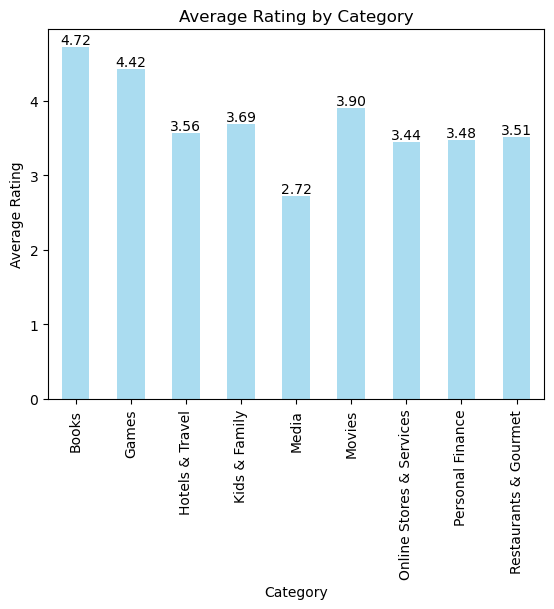

In [168]:
#Question 3.3: correlation between category and rating - represnted via bar chart.
category_ratings = df_clean.groupby('category')['rating'].mean()

# Plotting the bar chart
ax = category_ratings.plot(kind='bar', color='skyblue', alpha=0.7)

# Adding labels and title to the plot
plt.xlabel('Category')
plt.ylabel('Average Rating')
plt.title('Average Rating by Category')

# Adding mean values as annotations
for i, mean_rating in enumerate(category_ratings):
    ax.text(i, mean_rating, f'{mean_rating:.2f}', ha='center', va='bottom', color='black')

# Display the plot
plt.show()

##### Answer to Question 3.3: Summary of bar chart
The bar chart compares the mean rating accross the range of unique categories. It can be seen that Media has the lowest mean rating of 2.72, and Books has resulted in the highest mean rating of 4.72. 

The mean ratings for each category are as follows:
Books: 4.72
Games: 4.42
Hotels & Travel: 3.56
Kids & Family: 3.69
Media: 2.72
Movies:3.90
Online Stores & Services: 3.44
Personal Finance: 3.48
Restaurants & Gourmet:3.51

#### Q4. Detect and remove outliers

We may define outlier users, reviews and items with three rules (if a record meets one of the rules, it is regarded as an outlier):

1. reviews of which the helpfulness is no more than 2
2. users who rate less than 7 items
3. items that receives less than 11 ratings

Please remove the corresponding records in the csv file that involves outlier users, reviews and items. You need to follow the order of rules to perform data cleaning operations. After that, __print the length of the data__.

In [169]:
#Question 4.1:
# Droppiing the indexes which has helpfulness<=2 and displaying the altered result
df_helpfulness_clean = df_clean.drop(df_clean.index[df_clean['helpfulness']<=2])
df_helpfulness_clean

,userId,timestamp,review,item,rating,helpfulness,gender,category,item_id,item_price,user_city
2,33,12700,AOL..I love you!!!!!!!!!!!!,AOL (America Online),5.0,4.0,F,Online Stores & Services,0,145.84,31
3,33,21000,EBAY!!! I LOVE YOU!!!! :-)*,eBay,5.0,4.0,F,Online Stores & Services,88,149.00,31
4,33,22300,Blair Witch...Oh Come On.......,Blair Witch Project,1.0,4.0,F,Movies,12,44.00,31
6,33,32100,Go down under Mateys!!!!!,Outback Steakhouse,5.0,4.0,F,Restaurants & Gourmet,50,25.00,31
9,4053,22304,The best on the web.,Amazon.com,5.0,3.0,F,Online Stores & Services,3,129.82,22
...,...,...,...,...,...,...,...,...,...,...,...
19992,10805,11900,R.I.P,MTV,1.0,4.0,F,Media,39,138.00,18
19993,10805,12000,Leave them be...,Teletubbies,5.0,4.0,F,Kids & Family,76,48.25,18
19994,10805,50500,"Thank you, Drive Thru Please",McDonald's,3.0,3.0,F,Restaurants & Gourmet,41,30.74,18
19995,10805,50600,The Upper Class Fast Food,Wendy's,2.0,3.0,F,Restaurants & Gourmet,84,69.00,18


In [170]:
#Question 4.1: Lengh of data in which helpfulness in no more than 2.
print(len(df_helpfulness_clean))

13643


In [171]:
#Question 4.2:
#Grouping users by their ids and counting the number of their ratings
df_user = df_helpfulness_clean.groupby('userId').count()['item'].reset_index(name = 'count')
df_user

,userId,count
0,0,3
1,1,1
2,2,2
3,3,2
4,4,7
...,...,...
6530,10802,2
6531,10803,1
6532,10804,1
6533,10805,4


In [172]:
#Question 4.2:
#Finding the number of users who have rated less than 7 items
list_user_less7 = df_user[df_user['count']<7]['userId'].tolist()
list_user_less7

[0,
 1,
 2,
 3,
 7,
 8,
 9,
 11,
 12,
 13,
 14,
 15,
 16,
 17,
 19,
 20,
 21,
 22,
 25,
 26,
 27,
 28,
 29,
 30,
 31,
 33,
 34,
 35,
 36,
 39,
 40,
 42,
 43,
 44,
 47,
 48,
 49,
 53,
 54,
 55,
 58,
 59,
 60,
 61,
 62,
 64,
 66,
 67,
 68,
 69,
 70,
 72,
 73,
 76,
 77,
 79,
 80,
 83,
 84,
 85,
 88,
 90,
 93,
 94,
 95,
 96,
 97,
 98,
 100,
 101,
 102,
 103,
 104,
 105,
 107,
 108,
 109,
 110,
 112,
 113,
 115,
 117,
 118,
 121,
 123,
 124,
 125,
 126,
 127,
 129,
 130,
 132,
 133,
 136,
 138,
 139,
 141,
 142,
 144,
 145,
 147,
 148,
 149,
 150,
 151,
 152,
 153,
 155,
 156,
 157,
 158,
 159,
 160,
 161,
 162,
 164,
 166,
 167,
 168,
 169,
 170,
 171,
 172,
 174,
 176,
 177,
 181,
 182,
 183,
 184,
 186,
 187,
 189,
 190,
 191,
 193,
 194,
 196,
 197,
 198,
 199,
 200,
 201,
 202,
 203,
 204,
 206,
 207,
 208,
 209,
 210,
 211,
 212,
 213,
 215,
 217,
 219,
 220,
 222,
 223,
 224,
 225,
 227,
 228,
 230,
 231,
 234,
 236,
 237,
 238,
 239,
 240,
 242,
 246,
 247,
 248,
 250,
 251,
 252,
 

In [173]:
#Question 4.2:
##Dropping the no of users who have rated less than 7 items
df_user_clean = df_helpfulness_clean.drop(df_helpfulness_clean.index[df_helpfulness_clean['userId'].isin(list_user_less7)])
df_user_clean

,userId,timestamp,review,item,rating,helpfulness,gender,category,item_id,item_price,user_city
78,4081,71900,Not always McCrap,McDonald's,4.0,3.0,M,Restaurants & Gourmet,41,30.74,4
80,4081,72000,I dropped the chalupa even before he told me to,Taco Bell,1.0,4.0,M,Restaurants & Gourmet,74,108.30,4
81,4081,72000,The Wonderful World of Wendy,Wendy's,5.0,4.0,M,Restaurants & Gourmet,84,69.00,4
82,4081,100399,They actually did it,"South Park: Bigger, Longer & Uncut",5.0,3.0,M,Movies,68,143.11,4
83,4081,100399,Hey! Gimme some pie!,American Pie,3.0,3.0,M,Movies,6,117.89,4
...,...,...,...,...,...,...,...,...,...,...,...
19983,2445,22000,Great movie!,Austin Powers: The Spy Who Shagged Me,5.0,3.0,M,Movies,9,111.00,5
19985,2445,30700,Good food!,Outback Steakhouse,5.0,3.0,M,Restaurants & Gourmet,50,25.00,5
19988,2445,61500,Great movie!,Fight Club,5.0,3.0,M,Movies,26,97.53,5
19989,2445,100500,Awesome Game.,The Sims 2: Open for Business for Windows,5.0,4.0,M,Games,79,27.00,5


In [174]:
#Question 4.2: Length of data in which users rate less than 7.
print(len(df_user_clean))

2741


In [186]:
#Question 4.3:
#Counting the number of items by their ratings and displaying it in a tabular form
df_item = df_user_clean.groupby('item').count()['rating'].reset_index(name = 'count')
df_item

,item,count
0,AOL (America Online),93
1,All Advantage,72
2,Alta Vista (by 1stUp),10
3,Amazon.com,18
4,American Airlines,19
...,...,...
84,Wendy's,35
85,What Lies Beneath,28
86,X-Men,48
87,X.com,19


In [187]:
#Question 4.3:
#Displaying the items which have recieved less than 11 ratings
list_item_less11 = df_item[df_item['count']<11]['item'].tolist()
list_item_less11

['Alta Vista (by 1stUp)',
 'Earthlink',
 'Golden Eye 007 for Nintendo 64',
 'Luvs Ultra Leakguards Stretch',
 'Northwest Airlines',
 'Quicken Loans',
 'Sega Dreamcast Grey Console']

In [188]:
#Question 4.3:
#Dropping the items which have they have recieved less than 11 ratings
df_item_clean = df_user_clean.drop(df_user_clean.index[df_user_clean['item'].isin(list_item_less11)])
df_item_clean

,userId,timestamp,review,item,rating,helpfulness,gender,category,item_id,item_price,user_city
78,4081,71900,Not always McCrap,McDonald's,4.0,3.0,M,Restaurants & Gourmet,41,30.74,4
80,4081,72000,I dropped the chalupa even before he told me to,Taco Bell,1.0,4.0,M,Restaurants & Gourmet,74,108.30,4
81,4081,72000,The Wonderful World of Wendy,Wendy's,5.0,4.0,M,Restaurants & Gourmet,84,69.00,4
82,4081,100399,They actually did it,"South Park: Bigger, Longer & Uncut",5.0,3.0,M,Movies,68,143.11,4
83,4081,100399,Hey! Gimme some pie!,American Pie,3.0,3.0,M,Movies,6,117.89,4
...,...,...,...,...,...,...,...,...,...,...,...
19983,2445,22000,Great movie!,Austin Powers: The Spy Who Shagged Me,5.0,3.0,M,Movies,9,111.00,5
19985,2445,30700,Good food!,Outback Steakhouse,5.0,3.0,M,Restaurants & Gourmet,50,25.00,5
19988,2445,61500,Great movie!,Fight Club,5.0,3.0,M,Movies,26,97.53,5
19989,2445,100500,Awesome Game.,The Sims 2: Open for Business for Windows,5.0,4.0,M,Games,79,27.00,5


In [189]:
#Question 4.3: length of data of items that has received less than 11 rating
print(len(df_item_clean))

2685


In [190]:
#exporting the data
df_item_clean.to_csv('clean_data.csv', index = False)